# LGR5+ Crypt Marker-Removal MSE Figure

Train/evaluate the marker-removal conditions explored in the dcrypt-region analysis and generate one validation-error figures on originally LGR5-positive crypt domains. The LGR5+ crypt mask is always computed from the original validation graphs, so all bars compare the same biological node set.

In [61]:
import copy
import json
import pickle
import sys
from collections import deque
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

The settings mirror the current experiment notebooks. `REMOVAL_SETS` defines the marker-removal categories; each non-original category is evaluated both as eval-only removal and as train+eval removal.

In [ ]:
# Data and target settings
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and crypt-domain settings
VAL_FRAC = 0.3
SPLIT_SEED = None
DCRYPT_FIELD = "d_crypts_graph"
DCRYPT_CRYPT_MAX = 0.7
LGR5_MARKER_NAME = "LGR5"

# Marker-removal categories
REMOVAL_SETS = [
    {
        "key": "lgr5_removed",
        "label": "LGR5 removed",
        "markers": ["LGR5"],
    },
    {
        "key": "lysozyme_agr2_removed",
        "label": "Lysozyme+Agr2 removed",
        "markers": ["Lysozyme", "Agr2"],
    },
    {
        "key": "serotonin_chroma_removed",
        "label": "Serotonin+Chroma removed",
        "markers": ["Serotonin", "Chroma"],
    },
]

# Model settings
MODEL_CLASS = "GINCurvature"
NUM_LAYERS = 4
HIDDEN_DIM = 2 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Output settings
EXPERIMENT_GROUP = "lgr5_crypt_marker_removal_mse_figure"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
FIGURE_NAME = "lgr5_crypt_marker_removal_validation_mse"

In [63]:
def save_mpl_figure(fig, name, *, dpi=300):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figure -> {path}")
    return path


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def marker_index(name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if name in marker_names_in:
        return marker_names_in.index(name)
    lower = {str(m).lower(): i for i, m in enumerate(marker_names_in)}
    key = str(name).lower()
    if key not in lower:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names_in}")
    return lower[key]


def zero_marker_channels(graphs_in, marker_names_to_remove, marker_names_in, *, inplace=False):
    markers_to_remove = list(marker_names_to_remove)
    marker_indices = [marker_index(marker_name, marker_names_in) for marker_name in markers_to_remove]
    graphs_out = graphs_in if inplace else [copy.deepcopy(g) for g in graphs_in]
    info = {marker_name: 0 for marker_name in markers_to_remove}
    for g in graphs_out:
        g.x = g.x.clone()
        for marker_name, marker_idx in zip(markers_to_remove, marker_indices):
            info[marker_name] += int((g.x[:, marker_idx].detach().cpu().numpy() > 0.5).sum())
            g.x[:, marker_idx] = 0
    return graphs_out, info


RELATIVE_ERROR_EPS = 1e-8


def distribution_summary(values, prefix):
    vals = np.asarray(values, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {
            prefix: np.nan,
            f"sem_{prefix}": np.nan,
            f"std_{prefix}": np.nan,
            f"var_{prefix}": np.nan,
        }
    std = float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0
    return {
        prefix: float(np.mean(vals)),
        f"sem_{prefix}": float(std / np.sqrt(vals.size)) if vals.size > 1 else 0.0,
        f"std_{prefix}": std,
        f"var_{prefix}": float(std ** 2),
    }


def mse_distribution_summary(values):
    return distribution_summary(values, "mse")


def relative_abs_error_to_true_value(pred, *, eps=RELATIVE_ERROR_EPS):
    abs_err = np.abs(np.asarray(pred["y_pred"], dtype=float) - np.asarray(pred["y_true"], dtype=float))
    denom = np.abs(np.asarray(pred["y_true"], dtype=float)) + float(eps)
    out = np.full(abs_err.shape, np.nan, dtype=float)
    valid = np.isfinite(abs_err) & np.isfinite(denom)
    out[valid] = abs_err[valid] / denom[valid]
    return out


**Data Loading**

In [64]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)

Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Attached metadata to 1134/1134 graphs.
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [ ]:
# Optional day3p5 timepoint filter
from src.data.filters import filter_graphs_by_metadata

DAY3P5_TIMEPOINT = "day3p5"

# Default: remove day3p5 graphs if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

# Alternative: keep only day3p5 graphs and filter out all other timepoints.
# Uncomment this block and comment out the default block above if needed.
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     keep_values={DAY3P5_TIMEPOINT},
#     missing="drop",
#     inplace=False,
#     print_summary=True,
# )


**Filtering And Global Features**

In [65]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.metadata import (
    add_log_metadata_features,
    fill_missing_metadata_for_group,
    promote_metadata_to_graph_tensors,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)
g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)
graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)
graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    raise ValueError("This notebook requires USE_GLOBAL_FEATURES=True for the requested baselines.")

filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                243    341    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         288    409    0.704
20251201         day4p5              193    274    0.704
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------

**Split And Target Transform**

In [66]:
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

center_global, scale_global = standardize_graph_global_features(
    g_train,
    g_val,
    attr_name="global_feat",
    robust=False,
)

target_transform = AsinhStandardizeTransform(robust=True)
target_transform.fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)

Split -> train: 559 | val: 240
global_dim = 4
target_transform = asinh_standardize


**Training Setup**

In [67]:
from src.models.baseline import GlobalFeatureMLP
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device
print("device =", device)


def infer_target_dim_from_graphs(graphs_in):
    y = graphs_in[0].y
    return 1 if y.ndim == 1 else int(y.shape[1])


def make_gin_model(graphs_in, *, num_layers):
    return GINCurvature(
        n_markers=int(graphs_in[0].x.size(1)),
        global_dim=infer_global_dim(graphs_in),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(num_layers),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
        target_dim=infer_target_dim_from_graphs(graphs_in),
    )


def make_global_baseline(graphs_in):
    return GlobalFeatureMLP(
        global_dim=infer_global_dim(graphs_in),
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        target_dim=infer_target_dim_from_graphs(graphs_in),
    )

device = cuda


**Train Models**

The full model and the two controls are trained on the original data. For every marker-removal set, an additional full-depth model and depth-0 GIN are trained on the marker-removed train graphs. The global-only baseline is trained once because marker channels are invisible to it.

In [68]:
trained = {}
variant_graphs = {
    "original": {
        "label": "Original",
        "markers": [],
        "train": g_train,
        "val": g_val,
    }
}

print(f"Training original full-depth GIN | depth={NUM_LAYERS}")
model_full = make_gin_model(g_train, num_layers=NUM_LAYERS)
model_full, metrics_full, history_full = train(model_full, g_train, g_val, cfg)
trained[("original", "model")] = {"model": model_full, "metrics": metrics_full, "history": history_full}

print("Training global-only baseline")
model_global = make_global_baseline(g_train)
model_global, metrics_global, history_global = train(model_global, g_train, g_val, cfg)
trained[("original", "global_baseline")] = {"model": model_global, "metrics": metrics_global, "history": history_global}

print("Training GIN depth 0 baseline on original data")
model_gin0 = make_gin_model(g_train, num_layers=0)
model_gin0, metrics_gin0, history_gin0 = train(model_gin0, g_train, g_val, cfg)
trained[("original", "gin_depth0")] = {"model": model_gin0, "metrics": metrics_gin0, "history": history_gin0}

for spec in REMOVAL_SETS:
    key = spec["key"]
    markers = spec["markers"]
    g_train_removed, train_zero_info = zero_marker_channels(g_train, markers, marker_names, inplace=False)
    g_val_removed, val_zero_info = zero_marker_channels(g_val, markers, marker_names, inplace=False)
    variant_graphs[key] = {
        "label": spec["label"],
        "markers": list(markers),
        "train": g_train_removed,
        "val": g_val_removed,
        "train_zero_info": train_zero_info,
        "val_zero_info": val_zero_info,
    }
    print(f"Training full-depth GIN with {markers} removed in train/eval | depth={NUM_LAYERS}")
    model_removed = make_gin_model(g_train_removed, num_layers=NUM_LAYERS)
    model_removed, metrics_removed, history_removed = train(model_removed, g_train_removed, g_val_removed, cfg)
    trained[(key, "model")] = {"model": model_removed, "metrics": metrics_removed, "history": history_removed}

    print(f"Training GIN depth 0 with {markers} removed in train/eval")
    gin0_removed = make_gin_model(g_train_removed, num_layers=0)
    gin0_removed, metrics_gin0_removed, history_gin0_removed = train(gin0_removed, g_train_removed, g_val_removed, cfg)
    trained[(key, "gin_depth0")] = {
        "model": gin0_removed,
        "metrics": metrics_gin0_removed,
        "history": history_gin0_removed,
    }

print("Finished training all models.")

Training original full-depth GIN | depth=4
epoch 001 | train loss 0.6411 mae 0.8074 | val loss 0.5326 mae 0.7828
epoch 002 | train loss 0.5434 mae 0.7538 | val loss 0.4852 mae 0.7465
epoch 003 | train loss 0.4990 mae 0.7325 | val loss 0.4544 mae 0.7210
epoch 004 | train loss 0.4709 mae 0.7170 | val loss 0.4275 mae 0.7080
epoch 005 | train loss 0.4537 mae 0.7085 | val loss 0.4182 mae 0.7014
epoch 006 | train loss 0.4355 mae 0.6983 | val loss 0.4008 mae 0.6944
epoch 007 | train loss 0.4219 mae 0.6917 | val loss 0.4563 mae 0.7388
epoch 008 | train loss 0.4186 mae 0.6899 | val loss 0.3821 mae 0.6783
epoch 009 | train loss 0.4080 mae 0.6853 | val loss 0.3677 mae 0.6688
epoch 010 | train loss 0.3994 mae 0.6786 | val loss 0.4106 mae 0.7098
epoch 011 | train loss 0.3920 mae 0.6746 | val loss 0.3644 mae 0.6685
epoch 012 | train loss 0.3885 mae 0.6742 | val loss 0.3695 mae 0.6736
epoch 013 | train loss 0.3776 mae 0.6660 | val loss 0.4519 mae 0.7377
epoch 014 | train loss 0.3796 mae 0.6686 | val 

**LGR5+ Crypt Mask**

The mask is computed on the original validation graphs: a crypt connected component is LGR5-positive if any node in that component has positive LGR5 signal.

In [69]:
from src.data.metadata import get_graph_metadata


def _nanmin_or_nan(values, axis):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    filled = np.where(finite, arr, np.inf)
    out = np.min(filled, axis=axis)
    has_finite = np.any(finite, axis=axis)
    out = np.asarray(out, dtype=float)
    out[~has_finite] = np.nan
    return out


def _min_node_dcrypt_from_raw(raw, n_nodes):
    arr = np.asarray(raw, dtype=float)
    if arr.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    if arr.ndim == 0:
        return np.full(n_nodes, float(arr), dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] == n_nodes:
            return arr.astype(float)
        if arr.shape[0] == 1:
            return np.full(n_nodes, float(arr[0]), dtype=float)
        raise ValueError(f"Cannot align 1-D dcrypt with length {arr.shape[0]} to {n_nodes} nodes.")
    if n_nodes in arr.shape:
        node_axis = list(arr.shape).index(n_nodes)
        moved = np.moveaxis(arr, node_axis, 0).reshape(n_nodes, -1)
        return _nanmin_or_nan(moved, axis=1)
    if arr.ndim >= 2 and arr.shape[1] >= n_nodes:
        vals = _nanmin_or_nan(arr, axis=0)
    else:
        vals = _nanmin_or_nan(arr, axis=1)
    vals = np.asarray(vals, dtype=float).reshape(-1)
    if vals.shape[0] != n_nodes:
        raise ValueError(f"Transformed dcrypt has length {vals.shape[0]}, expected {n_nodes}.")
    return vals


def _build_undirected_adjacency(edge_index, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    ei = edge_index.detach().cpu().numpy() if hasattr(edge_index, "detach") else np.asarray(edge_index)
    for u, v in zip(ei[0], ei[1]):
        u = int(u)
        v = int(v)
        if u == v:
            continue
        adjacency[u].append(v)
        adjacency[v].append(u)
    return [sorted(set(neigh)) for neigh in adjacency]


def _connected_components_from_mask(adjacency, mask):
    mask = np.asarray(mask, dtype=bool)
    seen = np.zeros(len(mask), dtype=bool)
    components = []
    for start in np.where(mask)[0]:
        start = int(start)
        if seen[start]:
            continue
        queue = deque([start])
        seen[start] = True
        comp = []
        while queue:
            node = queue.popleft()
            comp.append(node)
            for nbr in adjacency[node]:
                if mask[nbr] and not seen[nbr]:
                    seen[nbr] = True
                    queue.append(nbr)
        components.append(sorted(comp))
    return components


def lgr5_positive_crypt_mask(graphs_in, *, meta_lookup, marker_names_in):
    lgr5_idx = marker_index(LGR5_MARKER_NAME, marker_names_in)
    parts = []
    domain_count = 0
    for g in graphs_in:
        n_nodes = int(g.x.shape[0])
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=False, default={})
        dvals = _min_node_dcrypt_from_raw(md.get(DCRYPT_FIELD, np.asarray([], dtype=float)), n_nodes)
        crypt_mask = np.isfinite(dvals) & (dvals < DCRYPT_CRYPT_MAX)
        out = np.zeros(n_nodes, dtype=bool)
        if np.any(crypt_mask):
            x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
            marker_pos = x[:, lgr5_idx] > 0.5
            adjacency = _build_undirected_adjacency(g.edge_index, n_nodes)
            for comp in _connected_components_from_mask(adjacency, crypt_mask):
                comp = np.asarray(comp, dtype=int)
                if np.any(marker_pos[comp]):
                    out[comp] = True
                    domain_count += 1
        parts.append(out)
    return np.concatenate(parts), domain_count


lgr5_crypt_mask, n_lgr5_crypt_domains = lgr5_positive_crypt_mask(
    g_val,
    meta_lookup=val_meta_lookup,
    marker_names_in=marker_names,
)
print("LGR5+ crypt nodes:", int(lgr5_crypt_mask.sum()))
print("LGR5+ crypt domains:", int(n_lgr5_crypt_domains))

def count_positive_marker_instances_in_mask(graphs_in, marker_names_to_count, marker_names_in, flat_mask):
    flat_mask = np.asarray(flat_mask, dtype=bool).reshape(-1)
    marker_indices = [marker_index(marker_name, marker_names_in) for marker_name in marker_names_to_count]
    total = 0
    by_marker = {marker_name: 0 for marker_name in marker_names_to_count}
    offset = 0
    for g in graphs_in:
        n = int(g.x.shape[0])
        local_mask = flat_mask[offset:offset + n]
        x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
        for marker_name, marker_idx in zip(marker_names_to_count, marker_indices):
            count = int(np.sum((x[:, marker_idx] > 0.5) & local_mask))
            by_marker[marker_name] += count
            total += count
        offset += n
    return total, by_marker


removed_marker_count_by_category = {"original": 0}
removed_marker_count_by_category_marker = {"original": {}}
for spec in REMOVAL_SETS:
    total, by_marker = count_positive_marker_instances_in_mask(
        g_val,
        spec["markers"],
        marker_names,
        lgr5_crypt_mask,
    )
    removed_marker_count_by_category[spec["key"]] = total
    removed_marker_count_by_category_marker[spec["key"]] = by_marker
    print(f"{spec['label']}: N={total} removed positive marker instances in plotted LGR5+ crypt nodes | {by_marker}")


LGR5+ crypt nodes: 12717
LGR5+ crypt domains: 252
LGR5 removed: N=6791 removed positive marker instances in plotted LGR5+ crypt nodes | {'LGR5': 6791}
Lysozyme+Agr2 removed: N=2312 removed positive marker instances in plotted LGR5+ crypt nodes | {'Lysozyme': 1108, 'Agr2': 1204}
Serotonin+Chroma removed: N=476 removed positive marker instances in plotted LGR5+ crypt nodes | {'Serotonin': 224, 'Chroma': 252}


**Evaluate Validation Errors**

In [70]:
from src.inference.predict import predict_targets


def predict_model_arrays(graphs_in, model_in):
    y_true_i, y_pred_i, log_var_i, _ = predict_targets(
        graphs_in,
        model_in,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )
    y_true_i = select_target_column(y_true_i, TARGET_INDEX_FOR_PLOTS)
    y_pred_i = select_target_column(y_pred_i, TARGET_INDEX_FOR_PLOTS)
    log_var_i = select_target_column(log_var_i, TARGET_INDEX_FOR_PLOTS)
    residual_i = y_pred_i - y_true_i
    sqerr_i = residual_i ** 2
    abserr_i = np.abs(residual_i)
    return {
        "y_true": y_true_i,
        "y_pred": y_pred_i,
        "log_var": log_var_i,
        "pred_var": np.exp(log_var_i),
        "residual": residual_i,
        "sqerr": sqerr_i,
        "abserr": abserr_i,
    }


def add_metric_row(
    rows,
    *,
    category_key,
    category_label,
    mode_key,
    mode_label,
    model_key,
    model_label,
    graphs_eval,
    model_in,
    trained_on,
    baseline_pred,
    pred_override=None,
):
    pred = pred_override if pred_override is not None else predict_model_arrays(graphs_eval, model_in)
    mask = np.asarray(lgr5_crypt_mask, dtype=bool)
    mse_stats = distribution_summary(pred["sqerr"][mask], "mse")
    mae_stats = distribution_summary(pred["abserr"][mask], "mae")
    rel_abs_err = relative_abs_error_to_true_value(pred)
    rel_stats = distribution_summary(rel_abs_err[mask], "mean_relative_error")
    row = {
        "category_key": category_key,
        "category": category_label,
        "mode_key": mode_key,
        "mode": mode_label,
        "model_key": model_key,
        "model": model_label,
        "trained_on": trained_on,
        "n_nodes": int(mask.sum()),
        "n_removed_marker_instances": int(removed_marker_count_by_category.get(category_key, 0)),
    }
    row.update(mse_stats)
    row.update(mae_stats)
    row.update(rel_stats)
    rows.append(row)
    return pred


metric_rows = []
predictions = {}

# Original condition.
baseline_pred_original = predict_model_arrays(g_val, model_global)
for model_key, model_label, model_in in [
    ("model", "Full GIN", model_full),
    ("global_baseline", "Global baseline", model_global),
    ("gin_depth0", "GIN depth 0", model_gin0),
]:
    predictions[("original", "original", model_key)] = add_metric_row(
        metric_rows,
        category_key="original",
        category_label="Original",
        mode_key="original",
        mode_label="Original",
        model_key=model_key,
        model_label=model_label,
        graphs_eval=g_val,
        model_in=model_in,
        trained_on="original",
        baseline_pred=baseline_pred_original,
        pred_override=baseline_pred_original if model_key == "global_baseline" else None,
    )

# Removal conditions.
for spec in REMOVAL_SETS:
    key = spec["key"]
    label = spec["label"]
    graphs_eval = variant_graphs[key]["val"]
    baseline_pred_removed = predict_model_arrays(graphs_eval, model_global)

    # Eval-only removal: original models are evaluated on marker-removed validation graphs.
    for model_key, model_label, model_in in [
        ("model", "Full GIN", model_full),
        ("global_baseline", "Global baseline", model_global),
        ("gin_depth0", "GIN depth 0", model_gin0),
    ]:
        predictions[(key, "eval_only", model_key)] = add_metric_row(
            metric_rows,
            category_key=key,
            category_label=label,
            mode_key="eval_only",
            mode_label="eval only",
            model_key=model_key,
            model_label=model_label,
            graphs_eval=graphs_eval,
            model_in=model_in,
            trained_on="original",
            baseline_pred=baseline_pred_removed,
            pred_override=baseline_pred_removed if model_key == "global_baseline" else None,
        )

    # Train+eval removal: full GIN and depth-0 GIN are trained on marker-removed data.
    # The global-only baseline is marker-blind, so the same trained model is shown as reference.
    for model_key, model_label, model_in, trained_on in [
        ("model", "Full GIN", trained[(key, "model")]["model"], key),
        ("global_baseline", "Global baseline", model_global, "original"),
        ("gin_depth0", "GIN depth 0", trained[(key, "gin_depth0")]["model"], key),
    ]:
        predictions[(key, "train_eval", model_key)] = add_metric_row(
            metric_rows,
            category_key=key,
            category_label=label,
            mode_key="train_eval",
            mode_label="train+eval",
            model_key=model_key,
            model_label=model_label,
            graphs_eval=graphs_eval,
            model_in=model_in,
            trained_on=trained_on,
            baseline_pred=baseline_pred_removed,
            pred_override=baseline_pred_removed if model_key == "global_baseline" else None,
        )

metrics_df = pd.DataFrame(metric_rows)
SAVE_DIR.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(SAVE_DIR / "lgr5_crypt_marker_removal_error_metrics.csv", index=False)
print(f"Saved metrics -> {SAVE_DIR / 'lgr5_crypt_marker_removal_error_metrics.csv'}")
metrics_df


Saved metrics -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/lgr5_crypt_marker_removal_mse_figure/run_20260530_110935/lgr5_crypt_marker_removal_error_metrics.csv


,category_key,category,mode_key,mode,model_key,model,trained_on,n_nodes,n_removed_marker_instances,mse,...,std_mse,var_mse,mae,sem_mae,std_mae,var_mae,mean_relative_error,sem_mean_relative_error,std_mean_relative_error,var_mean_relative_error
0,original,Original,original,Original,model,Full GIN,original,12717,0,0.003839,...,0.006699,0.000045,0.046625,0.000362,0.040811,0.001666,1.099633,0.077612,8.752276,76.602338
1,original,Original,original,Original,global_baseline,Global baseline,original,12717,0,0.007894,...,0.011552,0.000133,0.069991,0.000485,0.054729,0.002995,1.070332,0.065042,7.334716,53.798057
2,original,Original,original,Original,gin_depth0,GIN depth 0,original,12717,0,0.006069,...,0.009672,0.000094,0.059578,0.000445,0.050202,0.002520,1.016038,0.059834,6.747413,45.527586
3,lgr5_removed,LGR5 removed,eval_only,eval only,model,Full GIN,original,12717,6791,0.004111,...,0.007135,0.000051,0.048315,0.000374,0.042155,0.001777,1.115085,0.078905,8.898131,79.176729
4,lgr5_removed,LGR5 removed,eval_only,eval only,global_baseline,Global baseline,original,12717,6791,0.007894,...,0.011552,0.000133,0.069991,0.000485,0.054729,0.002995,1.070332,0.065042,7.334716,53.798057
5,lgr5_removed,LGR5 removed,eval_only,eval only,gin_depth0,GIN depth 0,original,12717,6791,0.007902,...,0.011489,0.000132,0.070320,0.000482,0.054381,0.002957,1.006253,0.054187,6.110606,37.339503
6,lgr5_removed,LGR5 removed,train_eval,train+eval,model,Full GIN,lgr5_removed,12717,6791,0.004020,...,0.007111,0.000051,0.047218,0.000375,0.042313,0.001790,1.077013,0.071495,8.062515,65.004148
7,lgr5_removed,LGR5 removed,train_eval,train+eval,global_baseline,Global baseline,original,12717,6791,0.007894,...,0.011552,0.000133,0.069991,0.000485,0.054729,0.002995,1.070332,0.065042,7.334716,53.798057
8,lgr5_removed,LGR5 removed,train_eval,train+eval,gin_depth0,GIN depth 0,lgr5_removed,12717,6791,0.007075,...,0.010789,0.000116,0.065236,0.000471,0.053097,0.002819,1.030530,0.063348,7.143681,51.032179
9,lysozyme_agr2_removed,Lysozyme+Agr2 removed,eval_only,eval only,model,Full GIN,original,12717,2312,0.004862,...,0.007978,0.000064,0.052877,0.000403,0.045459,0.002067,1.014160,0.059057,6.659874,44.353924


**Figure**

One bar chart contains the full model and both controls. Removed-marker categories are grouped as eval-only versus train+eval pairs.

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/lgr5_crypt_marker_removal_mse_figure/run_20260530_110935/figures/lgr5_crypt_marker_removal_validation_mse.pdf


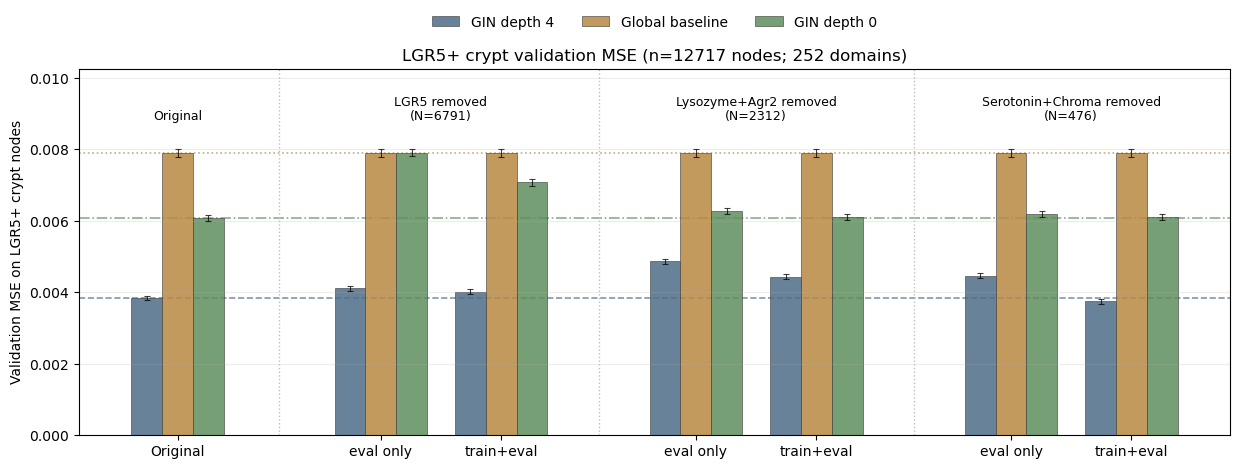

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/lgr5_crypt_marker_removal_mse_figure/run_20260530_110935/figures/lgr5_crypt_marker_removal_validation_mse_mae.pdf


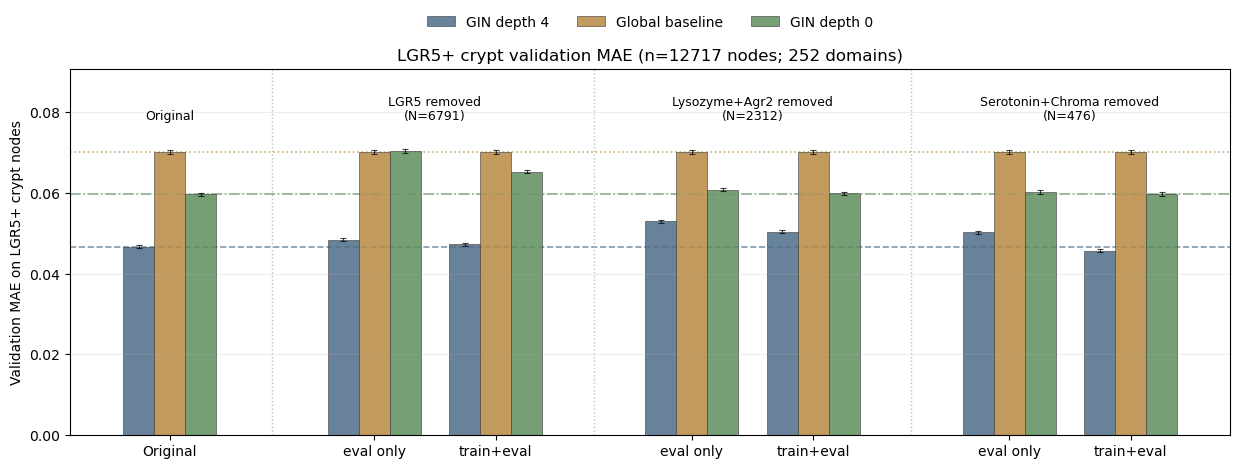

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/lgr5_crypt_marker_removal_mse_figure/run_20260530_110935/figures/lgr5_crypt_marker_removal_validation_mse_relative_error_vs_true_curvature.pdf


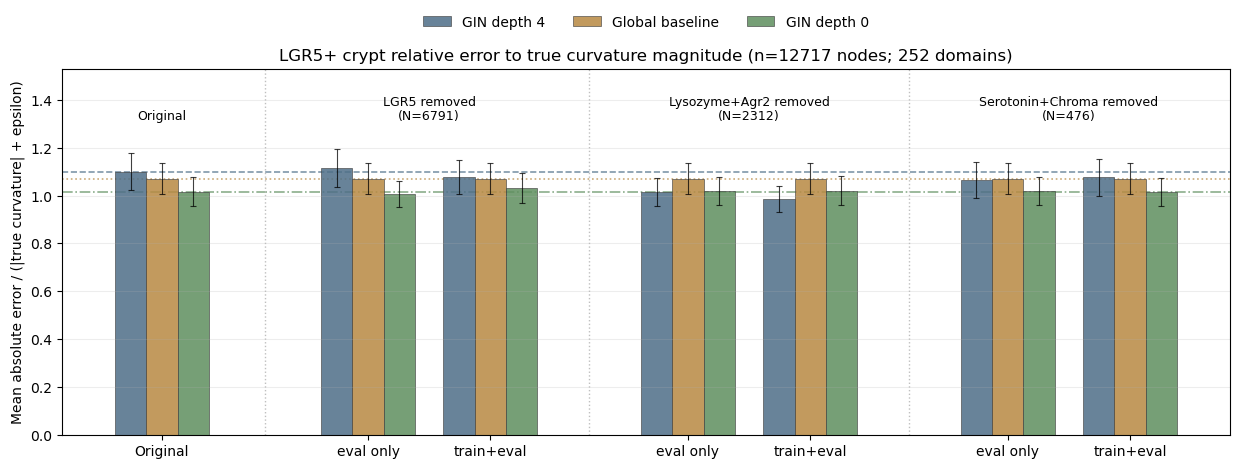

In [71]:
def plot_lgr5_crypt_error_metric(metrics_df, metric_col, sem_col, ylabel, title, filename):
    model_order = ["model", "global_baseline", "gin_depth0"]
    model_labels = {
        "model": f"GIN depth {NUM_LAYERS}",
        "global_baseline": "Global baseline",
        "gin_depth0": "GIN depth 0",
    }
    model_colors = {
        "model": "#4f6f88",
        "global_baseline": "#b88a44",
        "gin_depth0": "#5f8f5f",
    }
    reference_line_styles = {
        "model": "--",
        "global_baseline": ":",
        "gin_depth0": "-.",
    }

    condition_specs = [("original", "original", "Original", "")]
    for spec in REMOVAL_SETS:
        condition_specs.append((spec["key"], "eval_only", spec["label"], "eval only"))
        condition_specs.append((spec["key"], "train_eval", spec["label"], "train+eval"))

    x_positions = []
    tick_labels = []
    category_centers = []
    category_labels = []
    x = 0.0
    i = 0
    while i < len(condition_specs):
        category_key, mode_key, category_label, mode_label = condition_specs[i]
        if category_key == "original":
            x_positions.append(x)
            tick_labels.append("Original")
            category_centers.append(x)
            category_labels.append("Original")
            x += 1.45
            i += 1
        else:
            pair_positions = [x, x + 0.86]
            for pos, (_, mkey, _, mlabel) in zip(pair_positions, condition_specs[i:i + 2]):
                x_positions.append(pos)
                tick_labels.append(mlabel)
            category_centers.append(np.mean(pair_positions))
            n_removed = int(removed_marker_count_by_category.get(category_key, 0))
            category_labels.append(f"{category_label}\n(N={n_removed})")
            x += 2.25
            i += 2

    bar_width = 0.22
    offsets = (np.arange(len(model_order)) - (len(model_order) - 1) / 2) * bar_width

    fig, ax = plt.subplots(figsize=(12.5, 4.8))
    for model_offset, model_key in zip(offsets, model_order):
        heights = []
        errors = []
        for category_key, mode_key, _, _ in condition_specs:
            row = metrics_df[
                (metrics_df["category_key"] == category_key)
                & (metrics_df["mode_key"] == mode_key)
                & (metrics_df["model_key"] == model_key)
            ]
            if len(row) != 1:
                raise ValueError(f"Expected one row for {category_key}/{mode_key}/{model_key}, got {len(row)}")
            heights.append(float(row[metric_col].iloc[0]))
            errors.append(float(row[sem_col].iloc[0]))
        ax.bar(
            np.asarray(x_positions) + model_offset,
            heights,
            yerr=errors,
            width=bar_width,
            label=model_labels[model_key],
            color=model_colors[model_key],
            alpha=0.86,
            capsize=2,
            linewidth=0.5,
            edgecolor="0.25",
            error_kw={"elinewidth": 0.8, "capthick": 0.8, "alpha": 0.75},
        )

    # Reference lines mark each model's value on the original validation data.
    for model_key in model_order:
        ref_row = metrics_df[
            (metrics_df["category_key"] == "original")
            & (metrics_df["mode_key"] == "original")
            & (metrics_df["model_key"] == model_key)
        ]
        if len(ref_row) != 1:
            raise ValueError(f"Expected one original reference row for {model_key}, got {len(ref_row)}")
        ax.axhline(
            float(ref_row[metric_col].iloc[0]),
            color=model_colors[model_key],
            linestyle=reference_line_styles[model_key],
            linewidth=1.2,
            alpha=0.72,
            zorder=0,
        )

    # Visual separators between marker-removal categories.
    pair_boundaries = []
    for idx in range(len(x_positions) - 1):
        left_cat = condition_specs[idx][0]
        right_cat = condition_specs[idx + 1][0]
        if left_cat != right_cat:
            pair_boundaries.append((x_positions[idx] + x_positions[idx + 1]) / 2)
    for boundary in pair_boundaries:
        ax.axvline(boundary, color="0.75", linestyle=":", linewidth=1)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(tick_labels, rotation=0, ha="center")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.22)
    ax.legend(frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.18))

    ymin, ymax = ax.get_ylim()
    y_text = ymax + 0.04 * (ymax - ymin)
    for center, label in zip(category_centers, category_labels):
        ax.text(center, y_text, label, ha="center", va="bottom", fontsize=9, linespacing=1.15)
    ax.set_ylim(ymin, ymax + 0.22 * (ymax - ymin))

    fig.tight_layout()
    save_mpl_figure(fig, filename)
    return fig, ax


fig, ax = plot_lgr5_crypt_error_metric(
    metrics_df,
    "mse",
    "sem_mse",
    "Validation MSE on LGR5+ crypt nodes",
    f"LGR5+ crypt validation MSE (n={int(lgr5_crypt_mask.sum())} nodes; {n_lgr5_crypt_domains} domains)",
    FIGURE_NAME,
)
plt.show()

fig, ax = plot_lgr5_crypt_error_metric(
    metrics_df,
    "mae",
    "sem_mae",
    "Validation MAE on LGR5+ crypt nodes",
    f"LGR5+ crypt validation MAE (n={int(lgr5_crypt_mask.sum())} nodes; {n_lgr5_crypt_domains} domains)",
    f"{FIGURE_NAME}_mae",
)
plt.show()

fig, ax = plot_lgr5_crypt_error_metric(
    metrics_df,
    "mean_relative_error",
    "sem_mean_relative_error",
    "Mean absolute error / (|true curvature| + epsilon)",
    f"LGR5+ crypt relative error to true curvature magnitude (n={int(lgr5_crypt_mask.sum())} nodes; {n_lgr5_crypt_domains} domains)",
    f"{FIGURE_NAME}_relative_error_vs_true_curvature",
)
plt.show()


In [72]:
experiment_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_plots": TARGET_INDEX_FOR_PLOTS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "target_transform": target_transform.name,
    "dcrypt_field": DCRYPT_FIELD,
    "dcrypt_crypt_max": DCRYPT_CRYPT_MAX,
    "lgr5_marker_name": LGR5_MARKER_NAME,
    "removal_sets": REMOVAL_SETS,
    "model": {
        "class": MODEL_CLASS,
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
    },
    "filters": {
        "blacklist_n_keys": len(blacklist),
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "n_lgr5_crypt_nodes": int(lgr5_crypt_mask.sum()),
    "n_lgr5_crypt_domains": int(n_lgr5_crypt_domains),
    "removed_marker_count_by_category": removed_marker_count_by_category,
    "removed_marker_count_by_category_marker": removed_marker_count_by_category_marker,
    "relative_error_eps": RELATIVE_ERROR_EPS,
    "marker_names": list(marker_names),
    "figures_dir": str(FIGURES_DIR),
}

SAVE_DIR.mkdir(parents=True, exist_ok=True)
with open(SAVE_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)

training_logs = {
    f"{variant_key}__{model_key}": {
        "metrics": payload.get("metrics"),
        "history": payload.get("history"),
    }
    for (variant_key, model_key), payload in trained.items()
}
with open(SAVE_DIR / "training_logs.pkl", "wb") as f:
    pickle.dump(training_logs, f)

print(f"Saved config/logs -> {SAVE_DIR}")

Saved config/logs -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/lgr5_crypt_marker_removal_mse_figure/run_20260530_110935
